# Gaussian Mixture Models (GMM)

## ¿Qué es?

Modelo **probabilístico** que asume que los datos son generados por una mezcla de K distribuciones Gaussianas, cada una con sus propios parámetros:
- **μ** (media): centro del cluster
- **Σ** (covarianza): forma y orientación del cluster
- **π**: peso (probabilidad a priori) de cada componente

A diferencia de K-means, GMM:
- Puede modelar clusters **elípticos** (no solo esféricos)
- Devuelve **probabilidades** de pertenencia (asignación suave / soft clustering)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

%matplotlib inline


## Paso 1: Datos con clusters elípticos

Generamos datos donde las formas son alargadas para ver la ventaja de GMM.


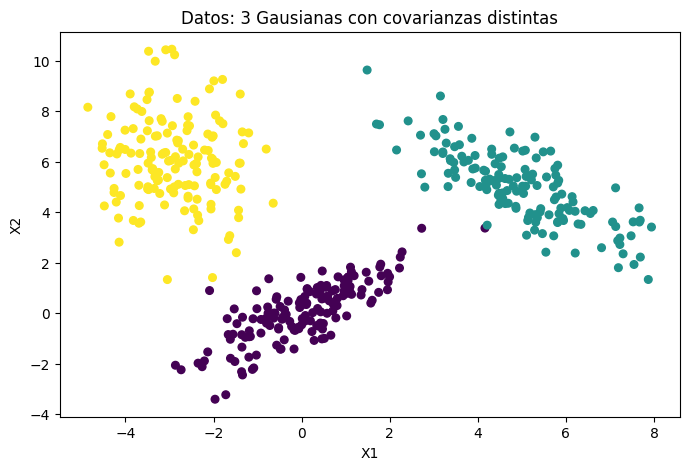

In [2]:
np.random.seed(42)

n = 150
mu1, cov1 = [0, 0], [[1.5, 1.2], [1.2, 1.5]]
mu2, cov2 = [5, 5], [[2, -1.5], [-1.5, 2]]
mu3, cov3 = [-3, 6], [[0.8, 0], [0, 3]]

X1 = np.random.multivariate_normal(mu1, cov1, n)
X2 = np.random.multivariate_normal(mu2, cov2, n)
X3 = np.random.multivariate_normal(mu3, cov3, n)

X = np.vstack([X1, X2, X3])
y_true = np.hstack([np.zeros(n), np.ones(n), np.full(n, 2)])

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30)
plt.title('Datos: 3 Gausianas con covarianzas distintas')
plt.xlabel('X1'); plt.ylabel('X2')
plt.show()


## Paso 2: Ajustar GMM


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probas = gmm.predict_proba(X_scaled)

print('Pesos (π):', np.round(gmm.weights_, 3))
print('Medias (μ) [escala estandarizada]:\n', np.round(gmm.means_, 3))
print()
print('Probabilidades (soft clustering) para los primeros 5 puntos:')
print(np.round(probas[:5], 3))


Pesos (π): [0.335 0.336 0.329]
Medias (μ) [escala estandarizada]:
 [[ 1.236  0.427]
 [-1.04   0.776]
 [-0.198 -1.229]]

Probabilidades (soft clustering) para los primeros 5 puntos:
[[0.    0.    1.   ]
 [0.    0.002 0.998]
 [0.    0.    1.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]]


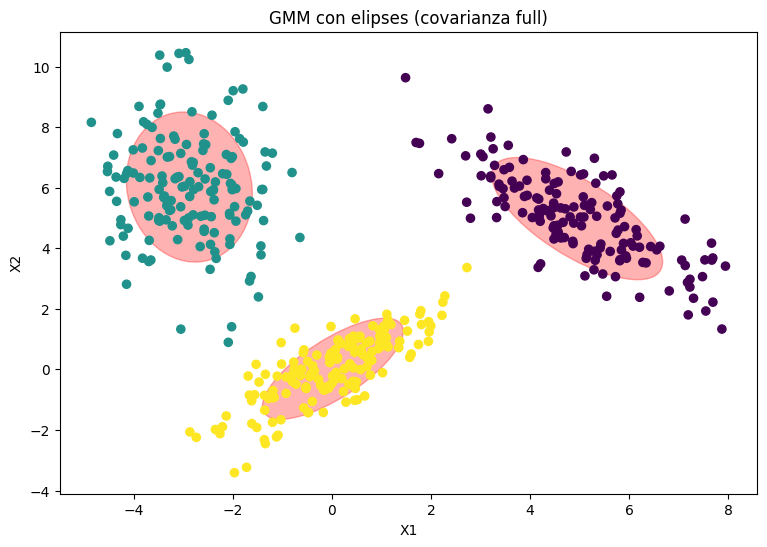

In [4]:
def plot_ellipses(gmm, ax, scaler):
    for i in range(gmm.n_components):
        mean_scaled = gmm.means_[i]
        cov_scaled = gmm.covariances_[i]
        mean_orig = scaler.inverse_transform(mean_scaled.reshape(1, -1))[0]
        v, w = np.linalg.eigh(cov_scaled)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        sx, sy = scaler.scale_
        ell = Ellipse(mean_orig, v[0] * sx, v[1] * sy, angle=180 + angle,
                      color='red', alpha=0.3, zorder=2)
        ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=35, zorder=3)
plot_ellipses(gmm, ax, scaler)
ax.set_title('GMM con elipses (covarianza full)')
ax.set_xlabel('X1'); ax.set_ylabel('X2')
plt.show()


## Paso 3: Tipos de covariance_type


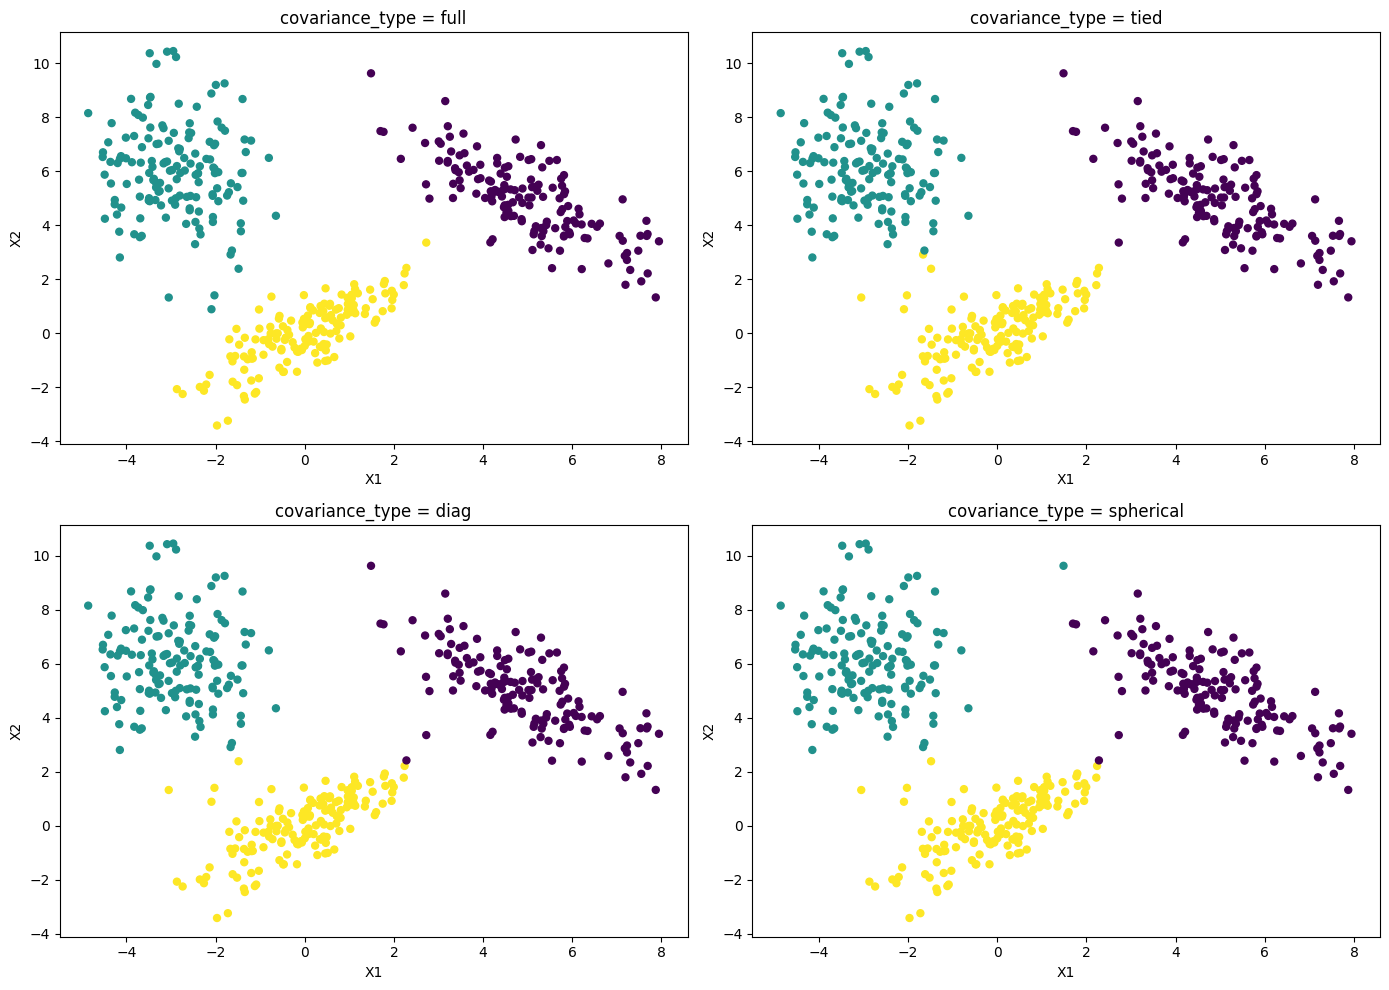

Significado:
- full: cada cluster tiene su propia matriz de covarianza (más flexible)
- tied: todos comparten la misma matriz de covarianza
- diag: covarianza diagonal (ejes alineados) independiente por cluster
- spherical: clusters esféricos (igual que K-means)


In [5]:
types = ['full', 'tied', 'diag', 'spherical']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, t in enumerate(types):
    gmm_t = GaussianMixture(n_components=3, covariance_type=t, random_state=42)
    lbls = gmm_t.fit_predict(X_scaled)
    axes[i].scatter(X[:, 0], X[:, 1], c=lbls, cmap='viridis', s=25)
    axes[i].set_title(f'covariance_type = {t}')
    axes[i].set_xlabel('X1'); axes[i].set_ylabel('X2')
plt.tight_layout()
plt.show()

print('Significado:')
print('- full: cada cluster tiene su propia matriz de covarianza (más flexible)')
print('- tied: todos comparten la misma matriz de covarianza')
print('- diag: covarianza diagonal (ejes alineados) independiente por cluster')
print('- spherical: clusters esféricos (igual que K-means)')


## Paso 4: Elegir K con BIC / AIC

BIC (Bayesian Information Criterion) y AIC (Akaike) penalizan modelos complejos. Buscamos el **mínimo**.


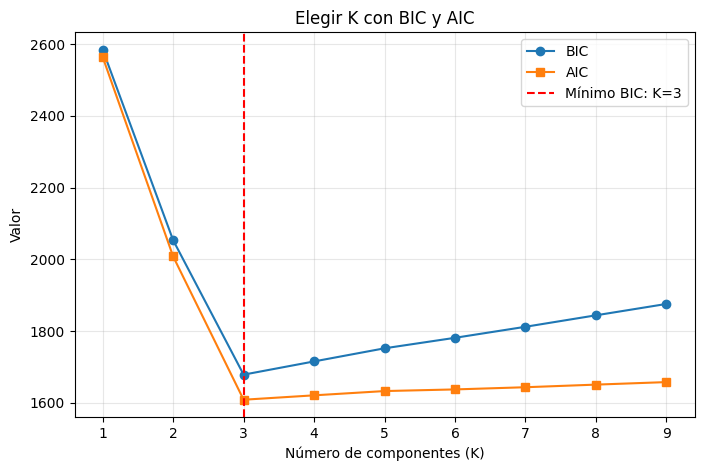

In [6]:
n_components_range = range(1, 10)
bics = []
aics = []

for k in n_components_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm_k.fit(X_scaled)
    bics.append(gmm_k.bic(X_scaled))
    aics.append(gmm_k.aic(X_scaled))

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, bics, marker='o', label='BIC')
plt.plot(n_components_range, aics, marker='s', label='AIC')
best_bic = np.argmin(bics) + 1
plt.axvline(best_bic, color='r', linestyle='--', label=f'Mínimo BIC: K={best_bic}')
plt.title('Elegir K con BIC y AIC')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Resumen

| Ventaja | Desventaja |
|---|---|
Clusters elípticos (formas flexibles) | Requiere K de antemano (aunque BIC ayuda) |
Asignación probabilística (soft clustering) | Puede converger a óptimos locales |
Interpretación probabilística intuitiva | Sensible a inicialización |
